In [82]:
import pandas as pd


In [83]:
import matplotlib.pyplot as plt
from utils import *

#################
## Larva Borns ##
#################

pro_df = local.read.csv("4_pro_larva_born_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')


pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("4_my_larva_born_transform", 'interim')
my_df

my_df2 = local.read.csv("3_extract_my_larva_borns", "interim")
my_df2

player_wons = []
larva_borns_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        larva_borns_scores.append(-1)
    else:
        my_score = float(temp_df.larva_born_count.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['larva_born_count'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['larva_born_count'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['larva_born_count'].quantile(0.80))
        if pro_score == 0:
            larva_borns_scores.append(1.0)
        else:
            larva_borns_scores.append(my_score/pro_score)

larva_borns_output_df = pd.DataFrame()
larva_borns_output_df['game_number'] = game_numbers
larva_borns_output_df['matchup'] = matchups
larva_borns_output_df['player_won'] = player_wons
larva_borns_output_df['larva_borns_score'] = larva_borns_scores
larva_borns_output_df

#############
## unspent ##
#############

pro_df = local.read.csv("8_pro_unspent_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("8_my_unspent_transform", 'interim')
my_df

my_df2 = local.read.csv("7_extract_my_unspent", "interim")
my_df2

# player_wons = []
unspent_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        unspent_scores.append(-1)
    else:
        my_score = float(temp_df.unspent_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['unspent_amount'].quantile(0.20))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['unspent_amount'].quantile(0.20))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['unspent_amount'].quantile(0.20))
        if my_score == 0:
            unspent_scores.append(0.0)
        else:
            unspent_scores.append(pro_score/my_score)

unspent_output_df = pd.DataFrame()
unspent_output_df['game_number'] = game_numbers
unspent_output_df['matchup'] = matchups
# unspent_output_df['player_won'] = player_wons
unspent_output_df['unspent_score'] = unspent_scores
unspent_output_df


#############
## larva ##
#############

pro_df = local.read.csv("12_pro_larva_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("12_my_larva_transform", 'interim')
my_df

my_df2 = local.read.csv("11_extract_my_larva", "interim")
my_df2

# player_wons = []
larva_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        larva_scores.append(-1)
    else:
        my_score = float(temp_df.larva_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['larva_amount'].quantile(0.20))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['larva_amount'].quantile(0.20))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['larva_amount'].quantile(0.20))
        if my_score == 0:
            larva_scores.append(0.0)
        else:
            larva_scores.append(pro_score/my_score)

larva_output_df = pd.DataFrame()
larva_output_df['game_number'] = game_numbers
larva_output_df['matchup'] = matchups
# larva_output_df['player_won'] = player_wons
larva_output_df['larva_score'] = larva_scores
larva_output_df


#############
## creep ##
#############

pro_df = local.read.csv("17_pro_creep_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("17_my_creep_transform", 'interim')
my_df

my_df2 = local.read.csv("16_extract_my_creeps", "interim")
my_df2

# player_wons = []
creep_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        creep_scores.append(-1)
    else:
        my_score = float(temp_df.creep_count.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['creep_count'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['creep_count'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['creep_count'].quantile(0.80))
        if pro_score == 0:
            creep_scores.append(1.0)
        else:
            creep_scores.append(my_score/pro_score)

creep_output_df = pd.DataFrame()
creep_output_df['game_number'] = game_numbers
creep_output_df['matchup'] = matchups
# creep_output_df['player_won'] = player_wons
creep_output_df['creep_score'] = creep_scores
creep_output_df


#############
## supply ##
#############

pro_df = local.read.csv("21_pro_supply_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("21_my_supply_transform", 'interim')
my_df

my_df2 = local.read.csv("20_extract_my_supply", "interim")
my_df2

# player_wons = []
supply_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        supply_scores.append(-1)
    else:
        my_score = float(temp_df.supply_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['supply_amount'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['supply_amount'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['supply_amount'].quantile(0.80))
        if pro_score == 0:
            supply_scores.append(1.0)
        else:
            supply_scores.append(my_score/pro_score)

supply_output_df = pd.DataFrame()
supply_output_df['game_number'] = game_numbers
supply_output_df['matchup'] = matchups
# supply_output_df['player_won'] = player_wons
supply_output_df['supply_score'] = supply_scores
supply_output_df


#############
## economy ##
#############

pro_df = local.read.csv("25_pro_economy_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("25_my_economy_transform", 'interim')
my_df

my_df2 = local.read.csv("24_extract_my_economy", "interim")
my_df2

# player_wons = []
economy_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        economy_scores.append(-1)
    else:
        my_score = float(temp_df.economy_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['economy_amount'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['economy_amount'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['economy_amount'].quantile(0.80))
        if pro_score == 0:
            economy_scores.append(1.0)
        else:
            economy_scores.append(my_score/pro_score)

economy_output_df = pd.DataFrame()
economy_output_df['game_number'] = game_numbers
economy_output_df['matchup'] = matchups
# economy_output_df['player_won'] = player_wons
economy_output_df['economy_score'] = economy_scores
economy_output_df


#############
## army ##
#############

pro_df = local.read.csv("29_pro_army_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("29_my_army_transform", 'interim')
my_df

my_df2 = local.read.csv("28_extract_my_army", "interim")
my_df2

# player_wons = []
army_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        army_scores.append(-1)
    else:
        my_score = float(temp_df.army_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['army_amount'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['army_amount'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['army_amount'].quantile(0.80))
        if pro_score == 0:
            army_scores.append(1.0)
        else:
            army_scores.append(my_score/pro_score)

army_output_df = pd.DataFrame()
army_output_df['game_number'] = game_numbers
army_output_df['matchup'] = matchups
# army_output_df['player_won'] = player_wons
army_output_df['army_score'] = army_scores
army_output_df


#############
## tech ##
#############

pro_df = local.read.csv("33_pro_tech_transform", 'interim')
pro_terran_df = pro_df.query('opponent_race == "Terran"')

pro_zerg_df = pro_df.query('opponent_race == "Zerg"')


pro_protoss_df = pro_df.query('opponent_race == "Protoss"')


my_df = local.read.csv("33_my_tech_transform", 'interim')
my_df

my_df2 = local.read.csv("32_extract_my_tech", "interim")
my_df2

# player_wons = []
tech_scores = []
game_numbers = []
matchups = []
for game_number in range(1, 333):
    temp_df = my_df[my_df['game_number'] == game_number].copy()
    temp_df2 = my_df2[my_df2['game_number'] == game_number].copy()
    if temp_df.shape[0] == 0:
        continue
        
    # player_wons.append(1 if temp_df2.iloc[0].main_player_won == 'Win' else 0)
    matchup = temp_df2.iloc[0].opponent_race
    game_numbers.append(game_number)
    matchups.append(matchup)
    max_second = max(temp_df.second)
    if max_second < 420:
        tech_scores.append(-1)
    else:
        my_score = float(temp_df.tech_amount.sum())
        if matchup == "Terran":
            pro_score = sum(pro_terran_df[pro_terran_df['second'] <= max_second].groupby('second')['tech_amount'].quantile(0.80))
        elif matchup == 'Zerg':
            pro_score = sum(pro_zerg_df[pro_zerg_df['second'] <= max_second].groupby('second')['tech_amount'].quantile(0.80))
        else:
            pro_score = sum(pro_protoss_df[pro_protoss_df['second'] <= max_second].groupby('second')['tech_amount'].quantile(0.80))
        if pro_score == 0:
            tech_scores.append(1.0)
        else:
            tech_scores.append(my_score/pro_score)

tech_output_df = pd.DataFrame()
tech_output_df['game_number'] = game_numbers
tech_output_df['matchup'] = matchups
# tech_output_df['player_won'] = player_wons
tech_output_df['tech_score'] = tech_scores
tech_output_df




,game_number,matchup,tech_score
0,1,Terran,0.941351
1,2,Zerg,1.247686
2,3,Terran,0.848329
3,4,Terran,0.939158
4,5,Terran,0.734265
...,...,...,...
238,326,Protoss,1.042356
239,327,Terran,1.134301
240,328,Zerg,0.941359
241,330,Zerg,0.868024


In [84]:
larva_borns_output_df, unspent_output_df, larva_output_df, creep_output_df, supply_output_df, economy_output_df, army_output_df, tech_output_df


(     game_number  matchup  player_won  larva_borns_score
 0              1   Terran           1           0.862458
 1              2     Zerg           1           0.960730
 2              3   Terran           1           0.896749
 3              4   Terran           0           0.918522
 4              5   Terran           1           0.867607
 ..           ...      ...         ...                ...
 238          326  Protoss           1           0.941193
 239          327   Terran           1           0.935845
 240          328     Zerg           1           0.840811
 241          330     Zerg           1           0.823088
 242          331     Zerg           1           0.909283
 
 [243 rows x 4 columns],
      game_number  matchup  unspent_score
 0              1   Terran       0.540606
 1              2     Zerg       0.384377
 2              3   Terran       0.729041
 3              4   Terran       0.730801
 4              5   Terran       0.543496
 ..           ...      ..

In [90]:
combined_df = pd.merge(larva_borns_output_df, unspent_output_df, on='game_number', how='left', suffixes=('_a', '_b'))
combined_df = pd.merge(combined_df, larva_output_df, on='game_number', how='left', suffixes=('', '_c'))
combined_df = pd.merge(combined_df, creep_output_df, on='game_number', how='left', suffixes=('', '_d'))
combined_df = pd.merge(combined_df, supply_output_df, on='game_number', how='left', suffixes=('', '_e'))
combined_df = pd.merge(combined_df, economy_output_df, on='game_number', how='left', suffixes=('', '_f'))
combined_df = pd.merge(combined_df, army_output_df, on='game_number', how='left', suffixes=('', '_g'))
combined_df = pd.merge(combined_df, tech_output_df, on='game_number', how='left', suffixes=('', '_h'))
combined_df = combined_df[[x for x in combined_df.columns if x == 'matchup_a' or 'matchup' not in x]].copy()
combined_df


,game_number,matchup_a,player_won,larva_borns_score,unspent_score,larva_score,creep_score,supply_score,economy_score,army_score,tech_score
0,1,Terran,1,0.862458,0.540606,0.800967,0.917382,0.885100,0.915834,0.715139,0.941351
1,2,Zerg,1,0.960730,0.384377,0.529732,2.736782,0.888218,1.068447,0.769372,1.247686
2,3,Terran,1,0.896749,0.729041,0.847003,0.525067,0.757532,0.828603,0.556715,0.848329
3,4,Terran,0,0.918522,0.730801,0.597432,1.353842,1.040079,0.947986,0.868403,0.939158
4,5,Terran,1,0.867607,0.543496,0.755232,1.005655,0.893540,0.864725,0.741931,0.734265
...,...,...,...,...,...,...,...,...,...,...,...
238,326,Protoss,1,0.941193,0.546165,0.602468,0.467091,0.929776,0.956212,0.728374,1.042356
239,327,Terran,1,0.935845,0.653925,0.568172,0.665351,0.951416,0.973237,0.700521,1.134301
240,328,Zerg,1,0.840811,0.561464,NaN,6.336849,0.945453,0.940032,0.835776,0.941359
241,330,Zerg,1,0.823088,0.456881,0.491851,NaN,0.928430,0.878337,0.759301,0.868024


In [91]:
combined_df.to_csv("output.csv")

In [142]:
combined_df.rename(columns={'larva_borns_score': 'larva_born_score'}, inplace=True)

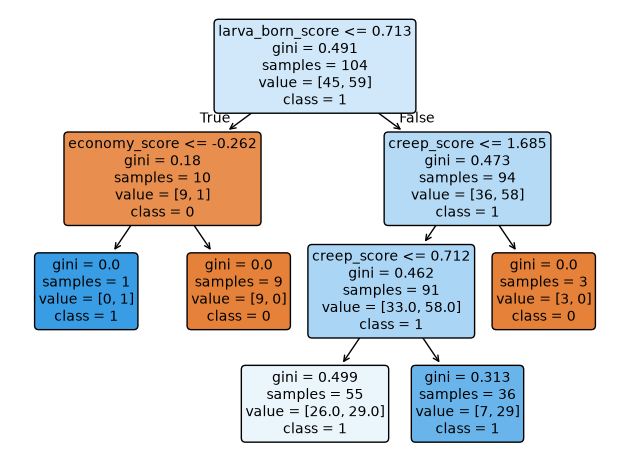

In [143]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
temp_df = combined_df.query("matchup_a == 'Terran'")
X = temp_df[[x for x in temp_df.columns if 'score' in x]].copy()
y = temp_df['player_won']
model = DecisionTreeClassifier(max_depth=3, random_state=1)
model.fit(X, y)
plt.figure()
plot_tree(model, feature_names=X.columns, class_names=[str(c) for c in model.classes_], filled=True, rounded=True, fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# Terran: Inject > creep
# Zerg: Make army > Win on Ling or Roach
# Protoss: Army > Creep

<Figure size 2600x500 with 0 Axes>

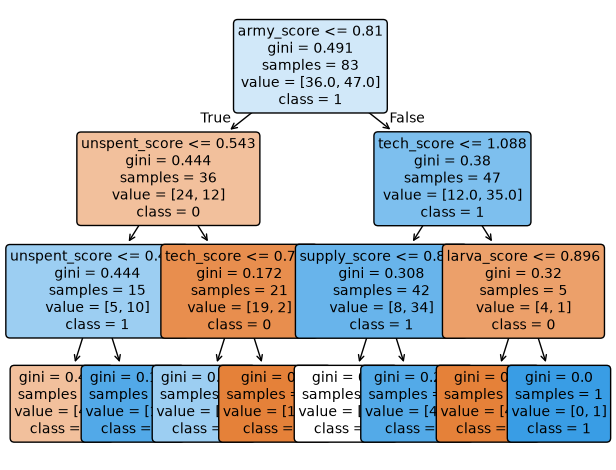

In [148]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
temp_df = combined_df.query("matchup_a == 'Zerg'")
X = temp_df[[x for x in temp_df.columns if 'score' in x]].copy()
y = temp_df['player_won']

plt.figure(figsize=(26,5))
model = DecisionTreeClassifier(max_depth=3, random_state=1)
model.fit(X, y)
plt.figure()
plot_tree(model, feature_names=X.columns, class_names=[str(c) for c in model.classes_], filled=True, rounded=True, fontsize=10)
plt.tight_layout()
plt.show()


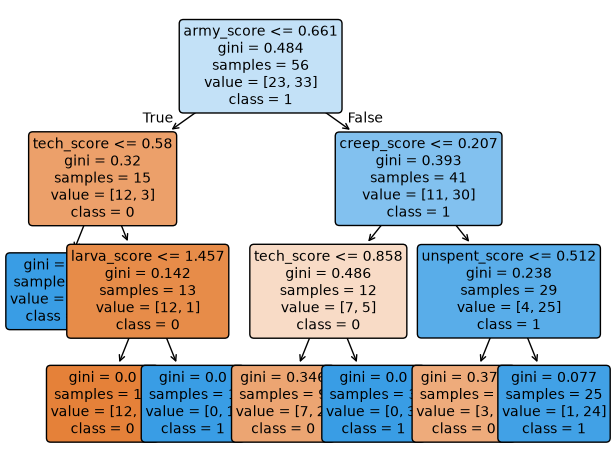

In [152]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
temp_df = combined_df.query("matchup_a == 'Protoss'")
X = temp_df[[x for x in temp_df.columns if 'score' in x]].copy()
y = temp_df['player_won']
model = DecisionTreeClassifier(max_depth=3, random_state=1)
model.fit(X, y)
plt.figure()
plot_tree(model, feature_names=X.columns, class_names=[str(c) for c in model.classes_], filled=True, rounded=True, fontsize=10)
plt.tight_layout()
plt.show()


In [153]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    monotone_constraints= (1, 1, 1, 1, 1, 1, 1, 1))


model.fit(X, y)

y_pred = model.predict(X)

from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.9107142857142857

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


accuracy_score(y_test, model.predict(X_test))

0.8333333333333334

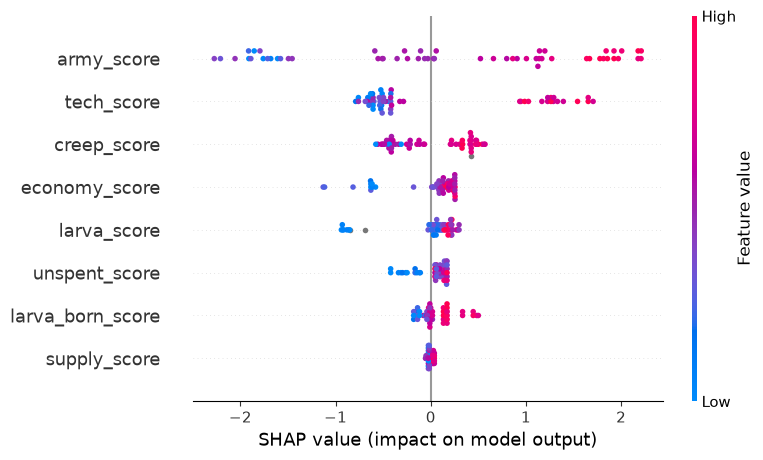

In [155]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [156]:
X

,larva_born_score,unspent_score,larva_score,creep_score,supply_score,economy_score,army_score,tech_score
15,0.804206,0.891910,0.834813,0.986363,0.851278,0.808395,0.743272,0.949737
21,0.868347,0.740781,0.763669,1.152911,0.942425,0.937862,0.918692,1.146705
22,0.859968,0.692824,0.711098,0.391162,0.828658,0.897989,0.670031,0.956167
24,0.907532,0.666823,0.789042,0.478295,0.975736,0.936884,0.942696,0.890668
26,0.750063,0.538307,0.928391,0.231051,0.785800,0.858418,0.677155,0.996872
30,0.918963,0.635546,0.862629,0.186929,1.021518,0.959075,0.785736,0.759112
32,0.728186,0.744217,1.219960,0.194051,0.667793,0.777033,0.690232,0.625570
37,0.827173,0.665468,0.819829,0.273950,0.898032,0.867215,0.838165,0.823095
46,0.884015,0.820065,0.924589,-1.000000,0.950017,0.892916,0.868205,0.865688
53,0.843178,0.635631,0.810603,0.285003,0.906997,0.838598,0.913535,0.962163


In [172]:
temp_df[temp_df['army_score'] >= 0.80].player_won.agg(['mean', 'count'])

mean      0.875
count    16.000
Name: player_won, dtype: float64

In [170]:
temp_df.player_won.agg(['mean', 'count'])


mean      0.589286
count    56.000000
Name: player_won, dtype: float64

In [174]:
combined_df


,game_number,matchup_a,player_won,larva_born_score,unspent_score,larva_score,creep_score,supply_score,economy_score,army_score,tech_score
0,1,Terran,1,0.862458,0.540606,0.800967,0.917382,0.885100,0.915834,0.715139,0.941351
1,2,Zerg,1,0.960730,0.384377,0.529732,2.736782,0.888218,1.068447,0.769372,1.247686
2,3,Terran,1,0.896749,0.729041,0.847003,0.525067,0.757532,0.828603,0.556715,0.848329
3,4,Terran,0,0.918522,0.730801,0.597432,1.353842,1.040079,0.947986,0.868403,0.939158
4,5,Terran,1,0.867607,0.543496,0.755232,1.005655,0.893540,0.864725,0.741931,0.734265
...,...,...,...,...,...,...,...,...,...,...,...
238,326,Protoss,1,0.941193,0.546165,0.602468,0.467091,0.929776,0.956212,0.728374,1.042356
239,327,Terran,1,0.935845,0.653925,0.568172,0.665351,0.951416,0.973237,0.700521,1.134301
240,328,Zerg,1,0.840811,0.561464,NaN,6.336849,0.945453,0.940032,0.835776,0.941359
241,330,Zerg,1,0.823088,0.456881,0.491851,NaN,0.928430,0.878337,0.759301,0.868024
